# 1. Setup and Imports

This first cell imports all necessary libraries from PyTorch, TorchVision, and Matplotlib. It also sets up the device (CUDA/GPU if available, otherwise CPU).

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import vgg19
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt
import numpy as np
import os

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create a directory for results
os.makedirs("results", exist_ok=True)

Using device: cuda


# 2. Hyperparameters
We define all our training parameters in one place.

In [2]:
# Hyperparameters
EPOCHS = 25           # @param {type:"integer"}
BATCH_SIZE = 128      # @param {type:"integer"}
LEARNING_RATE = 1e-3  # @param {type:"number"}
LATENT_DIM = 32       # @param {type:"integer"} Dimensionality of the latent space
IMG_SIZE = 32         # @param {type:"number"} VGG works better with 32x32 or larger
IMG_CHANNELS = 3      # @param {type:"number"} We'll duplicate the grayscale channel to 3
BETA = 0.5            # @param {type:"number"} Weight for the KL divergence term (beta-VAE)

# 3. Data Loading
We load the Fashion-MNIST dataset. We apply two important transformations:

`Resize(IMG_SIZE)`: Upscales the 28x28 images to 32x32.

`Lambda(...)`: Converts the 1-channel grayscale image to a 3-channel image by repeating the channel. This is necessary for the VGG network.

In [3]:
# Define transformations
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(IMG_CHANNELS, 1, 1))
])

# Download and load the training data
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Download and load the test data
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 178kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 17.8MB/s]


# 4. Perceptual Loss (VGG)

This is the core of the custom loss. We create a class that loads a pre-trained VGG19 model. It extracts features from specific intermediate layers and calculates the L1 loss between the features of the original image and the reconstructed image.

Note: It's crucial to normalize the images (using ImageNet stats) before passing them to VGG, as VGG was trained on normalized images.

In [4]:
class VGGPerceptualLoss(nn.Module):
    def __init__(self):
        super(VGGPerceptualLoss, self).__init__()
        # Load pre-trained VGG19
        vgg = vgg19(pretrained=True).features
        vgg.eval()

        # --- FIX 1: Disable inplace ReLU ---
        # Iterate through all VGG modules
        for module in vgg.modules():
            if isinstance(module, nn.ReLU):
                # Set inplace=False for all ReLU activations
                module.inplace = False
        # ------------------------------------

        # Freeze VGG parameters
        for param in vgg.parameters():
            param.requires_grad = False

        # --- FIX 2: Correctly slice the network ---
        # We want features from relu1_1, relu2_1, relu3_1, and relu4_1
        # The indices for these layers in vgg.features are:
        # relu1_1: 1
        # relu2_1: 6
        # relu3_1: 11
        # relu4_1: 20

        # Create sequential slices
        self.slice1 = nn.Sequential(*[vgg[i] for i in range(2)])   # Up to relu1_1
        self.slice2 = nn.Sequential(*[vgg[i] for i in range(2, 7)])  # From conv1_2 to relu2_1
        self.slice3 = nn.Sequential(*[vgg[i] for i in range(7, 12)]) # From conv2_2 to relu3_1
        self.slice4 = nn.Sequential(*[vgg[i] for i in range(12, 21)])# From conv3_2 to relu4_1
        # ------------------------------------------

        # ImageNet normalization values
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def normalize(self, x):
        # Normalize input images for VGG
        return (x - self.mean) / self.std

    def forward(self, x_recon, x_real):
        # Normalize inputs for VGG
        x_recon_norm = self.normalize(x_recon)
        x_real_norm = self.normalize(x_real)

        # Pass images through the network, extracting features at each slice
        h_recon = self.slice1(x_recon_norm)
        h_real = self.slice1(x_real_norm)
        loss = F.l1_loss(h_recon, h_real)

        h_recon = self.slice2(h_recon)
        h_real = self.slice2(h_real)
        loss += F.l1_loss(h_recon, h_real)

        h_recon = self.slice3(h_recon)
        h_real = self.slice3(h_real)
        loss += F.l1_loss(h_recon, h_real)

        h_recon = self.slice4(h_recon)
        h_real = self.slice4(h_real)
        loss += F.l1_loss(h_recon, h_real)

        return loss

# 5. VAE Model Definition

We define a standard Convolutional VAE architecture with an Encoder and a Decoder.

- Encoder: Compresses the 3x32x32 image into a latent vector (`mu` and `log_var`).
- Decoder: Reconstructs the 3x32x32 image from a sample (`z`) from the latent space.
- VAE: Ties them together, implements the reparameterization trick, and defines the forward pass.

In [5]:
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(IMG_CHANNELS, 32, kernel_size=4, stride=2, padding=1),  # 32x32 -> 16x16
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),           # 16x16 -> 8x8
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),          # 8x8 -> 4x4
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128 * 4 * 4, LATENT_DIM)
        self.fc_log_var = nn.Linear(128 * 4 * 4, LATENT_DIM)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        return mu, log_var

class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.fc = nn.Linear(LATENT_DIM, 128 * 4 * 4)
        self.deconv_layers = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 4x4 -> 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 8x8 -> 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, IMG_CHANNELS, kernel_size=4, stride=2, padding=1), # 16x16 -> 32x32
            nn.Sigmoid()  # Output images in [0, 1] range
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 128, 4, 4)
        x = self.deconv_layers(x)
        return x

class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, log_var = self.encoder(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

    def sample(self, num_samples=64):
        z = torch.randn(num_samples, LATENT_DIM).to(device)
        return self.decoder(z)

# 6. Initialize Model, Loss, and Optimizer

We instantiate the VAE, the perceptual loss function, and the Adam optimizer.

In [6]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
perceptual_loss_fn = VGGPerceptualLoss().to(device)

def loss_function(x_recon, x_real, mu, log_var):
    # 1. Perceptual Loss (Reconstruction)
    recon_loss = perceptual_loss_fn(x_recon, x_real)

    # 2. KL Divergence
    # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    # Normalize by batch size
    kl_loss = kl_loss / x_real.size(0)

    # Total loss
    total_loss = recon_loss + BETA * kl_loss

    return total_loss, recon_loss, kl_loss

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 238MB/s]


# 7. Training Loop

This is the main training loop. For each batch, we compute the total loss (Perceptual Loss + KL Divergence) and update the model weights.

In [8]:
print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        # Forward pass
        x_recon, mu, log_var = model(data)

        # Calculate loss
        loss, recon_loss, kl_loss = loss_function(x_recon, data, mu, log_var)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kl_loss_total += kl_loss.item()

    # Log epoch results
    avg_loss = train_loss / len(train_loader)
    avg_recon_loss = recon_loss_total / len(train_loader)
    avg_kl_loss = kl_loss_total / len(train_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}, "
          f"Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}")

    # Save reconstructed images and samples every 5 epochs
    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            # Get a batch of test images
            test_data = next(iter(test_loader))[0].to(device)

            # Reconstruct
            x_recon, _, _ = model(test_data)

            # Combine real and reconstructed
            comparison = torch.cat([test_data[:16], x_recon[:16]])
            comparison_grid = make_grid(comparison, nrow=16)
            save_image(comparison_grid, f"results/recon_epoch_{epoch+1}.png")

            # Generate new samples
            samples = model.sample(64)
            sample_grid = make_grid(samples)
            save_image(sample_grid, f"results/sample_epoch_{epoch+1}.png")

print("Training finished.")

Starting training...
Epoch [1/25], Loss: 6.7782, Recon Loss: 6.6917, KL Loss: 0.1730
Epoch [2/25], Loss: 6.1838, Recon Loss: 5.8748, KL Loss: 0.6180
Epoch [3/25], Loss: 6.0006, Recon Loss: 5.4835, KL Loss: 1.0343
Epoch [4/25], Loss: 5.9062, Recon Loss: 5.3001, KL Loss: 1.2123
Epoch [5/25], Loss: 5.8677, Recon Loss: 5.2228, KL Loss: 1.2898
Epoch [6/25], Loss: 5.8429, Recon Loss: 5.1835, KL Loss: 1.3189
Epoch [7/25], Loss: 5.8321, Recon Loss: 5.1597, KL Loss: 1.3449
Epoch [8/25], Loss: 5.8208, Recon Loss: 5.1404, KL Loss: 1.3608
Epoch [9/25], Loss: 5.8167, Recon Loss: 5.1289, KL Loss: 1.3757
Epoch [10/25], Loss: 5.8096, Recon Loss: 5.1237, KL Loss: 1.3719
Epoch [11/25], Loss: 5.8049, Recon Loss: 5.1157, KL Loss: 1.3784
Epoch [12/25], Loss: 5.8013, Recon Loss: 5.1091, KL Loss: 1.3844
Epoch [13/25], Loss: 5.7991, Recon Loss: 5.1092, KL Loss: 1.3798
Epoch [14/25], Loss: 5.7975, Recon Loss: 5.1032, KL Loss: 1.3887
Epoch [15/25], Loss: 5.7920, Recon Loss: 5.0949, KL Loss: 1.3942
Epoch [16/25]

# 8. Visualization

After training, we'll visualize the results. We show a comparison of original test images vs. their reconstructions, and we show brand new images generated by sampling from the latent space.

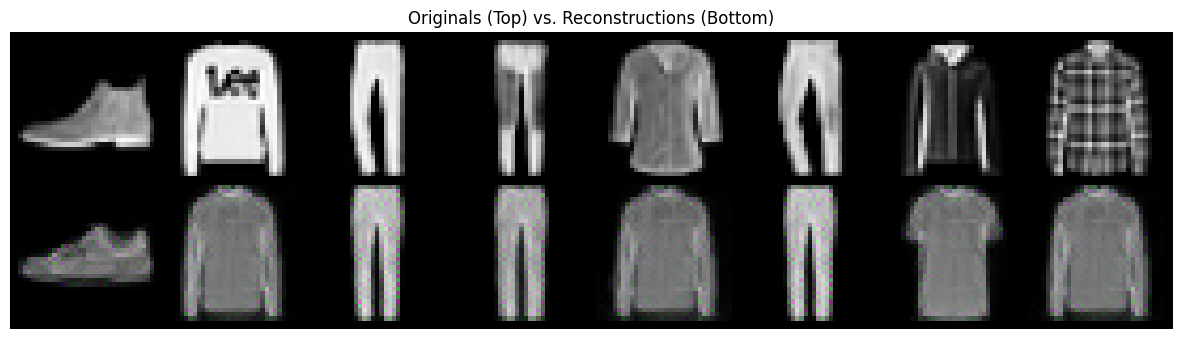

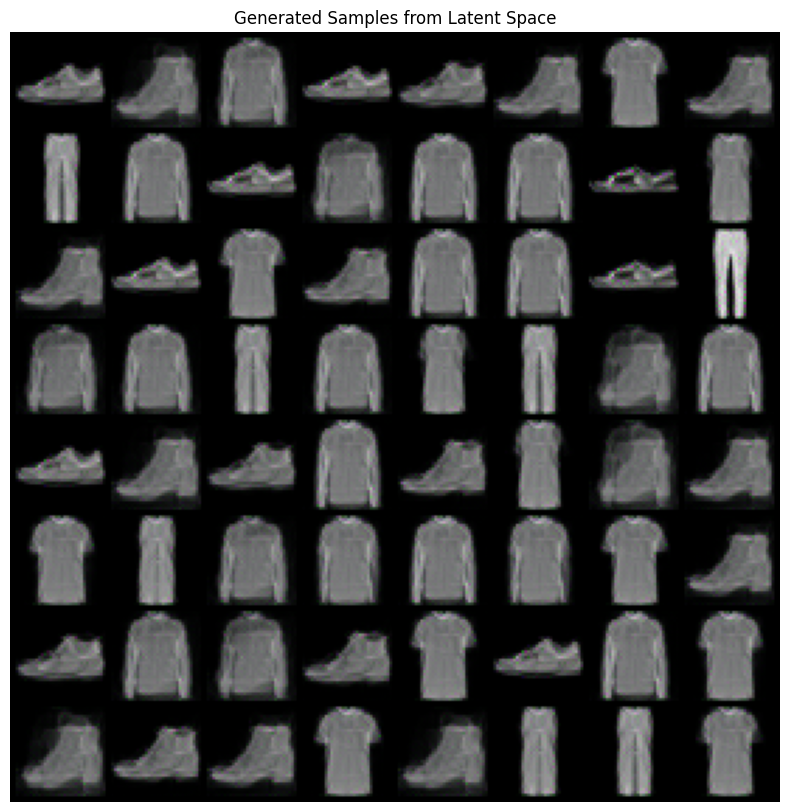

In [9]:
def imshow(img, title):
    npimg = img.cpu().numpy()
    plt.figure(figsize=(15, 10))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# 1. Show Reconstructions
model.eval()
with torch.no_grad():
    # Get a batch of test images
    test_data = next(iter(test_loader))[0].to(device)

    # Reconstruct
    x_recon, _, _ = model(test_data)

    # Select 8 images to show
    n_images = 8

    # Combine real and reconstructed
    comparison = torch.cat([
        test_data[:n_images],
        x_recon[:n_images]
    ])

    comparison_grid = make_grid(comparison, nrow=n_images)
    imshow(comparison_grid, "Originals (Top) vs. Reconstructions (Bottom)")

# 2. Show Generated Samples
model.eval()
with torch.no_grad():
    # Generate new samples
    samples = model.sample(64).cpu()
    sample_grid = make_grid(samples, nrow=8)
    imshow(sample_grid, "Generated Samples from Latent Space")

# 9. Comparing against common Loss (pixel-wise loss)

In [ ]:
def common_loss(x_recon, x_real, mu, log_var):
  recon_loss = (x_recon - x_real).pow(2).mean()
  kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
  kl_loss = kl_loss / x_real.size(0)

  total_loss = recon_loss + BETA * kl_loss
  return total_loss, recon_loss, kl_loss

In [10]:
model2 = VAE().to(device)
optimizer2 = optim.Adam(model2.parameters(), lr=LEARNING_RATE)

print("Starting training...")

for epoch in range(EPOCHS):
    model2.train()
    train_loss = 0
    recon_loss_total = 0
    kl_loss_total = 0

    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)

        # Forward pass
        x_recon, mu, log_var = model2(data)

        # Calculate loss
        loss, recon_loss, kl_loss = common_loss(x_recon, data, mu, log_var)

        # Backward pass
        optimizer2.zero_grad()
        loss.backward()
        optimizer2.step()

        train_loss += loss.item()
        recon_loss_total += recon_loss.item()
        kl_loss_total += kl_loss.item()

    # Log epoch results
    avg_loss = train_loss / len(train_loader)
    avg_recon_loss = recon_loss_total / len(train_loader)
    avg_kl_loss = kl_loss_total / len(train_loader)

    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {avg_loss:.4f}, "
          f"Recon Loss: {avg_recon_loss:.4f}, KL Loss: {avg_kl_loss:.4f}")

    # Save reconstructed images and samples every 5 epochs
    if (epoch + 1) % 5 == 0:
        model2.eval()
        with torch.no_grad():
            # Get a batch of test images
            test_data = next(iter(test_loader))[0].to(device)

            # Reconstruct
            x_recon, _, _ = model2(test_data)

            # Combine real and reconstructed
            comparison = torch.cat([test_data[:16], x_recon[:16]])
            comparison_grid = make_grid(comparison, nrow=16)
            save_image(comparison_grid, f"results/recon_epoch_{epoch+1}.png")

            # Generate new samples
            samples = model2.sample(64)
            sample_grid = make_grid(samples)
            save_image(sample_grid, f"results/sample_epoch_{epoch+1}.png")

print("Training finished.")

Starting training...
Epoch [1/25], Loss: 0.0832, Recon Loss: 0.0831, KL Loss: 0.0001
Epoch [2/25], Loss: 0.0780, Recon Loss: 0.0780, KL Loss: 0.0000
Epoch [3/25], Loss: 0.0778, Recon Loss: 0.0778, KL Loss: 0.0000
Epoch [4/25], Loss: 0.0778, Recon Loss: 0.0778, KL Loss: 0.0000
Epoch [5/25], Loss: 0.0778, Recon Loss: 0.0778, KL Loss: 0.0000
Epoch [6/25], Loss: 0.0778, Recon Loss: 0.0778, KL Loss: 0.0000
Epoch [7/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [8/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [9/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [10/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [11/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [12/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [13/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [14/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [15/25], Loss: 0.0777, Recon Loss: 0.0777, KL Loss: 0.0000
Epoch [16/25]

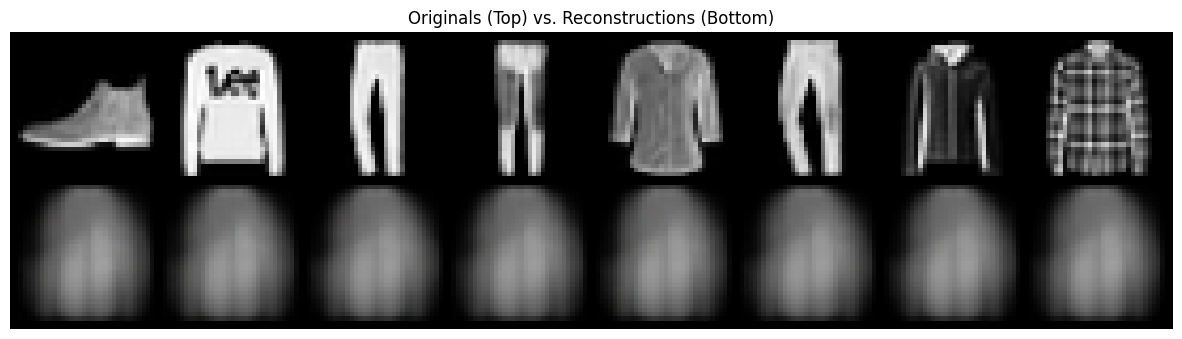

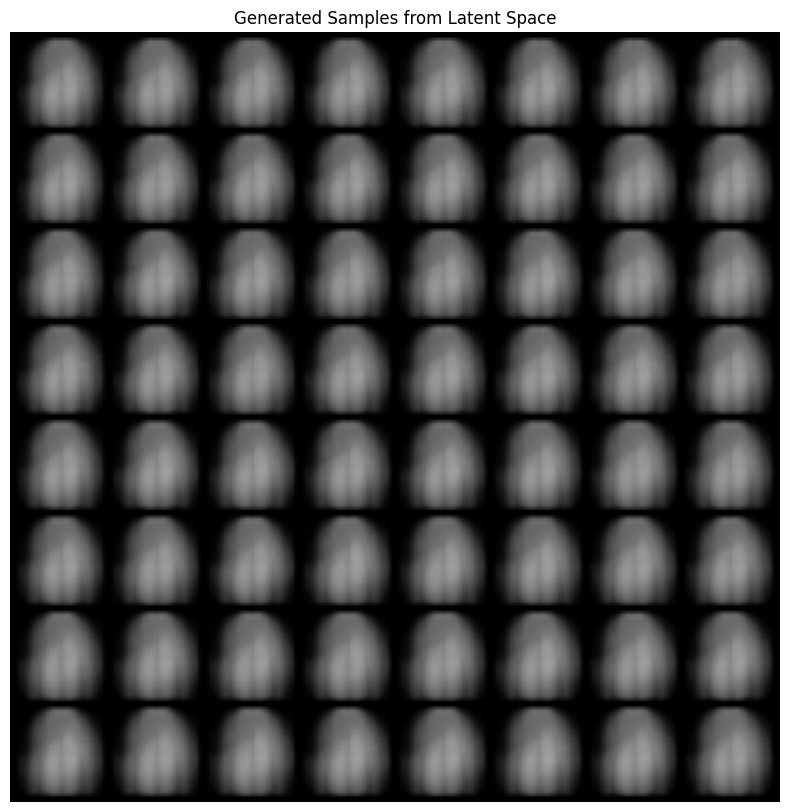

In [11]:
def imshow(img, title):
    npimg = img.cpu().numpy()
    plt.figure(figsize=(15, 10))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

# 1. Show Reconstructions
model2.eval()
with torch.no_grad():
    # Get a batch of test images
    test_data = next(iter(test_loader))[0].to(device)

    # Reconstruct
    x_recon, _, _ = model2(test_data)

    # Select 8 images to show
    n_images = 8

    # Combine real and reconstructed
    comparison = torch.cat([
        test_data[:n_images],
        x_recon[:n_images]
    ])

    comparison_grid = make_grid(comparison, nrow=n_images)
    imshow(comparison_grid, "Originals (Top) vs. Reconstructions (Bottom)")

# 2. Show Generated Samples
model2.eval()
with torch.no_grad():
    # Generate new samples
    samples = model2.sample(64).cpu()
    sample_grid = make_grid(samples, nrow=8)
    imshow(sample_grid, "Generated Samples from Latent Space")